# M4-B2 — Vision PCB Defect (binôme async)

Auteurs : `Romain` version de travail — Date : `08/07/2026`

**Conventions** :
- `random_state=42`
- Pas de `print` excessif
- `Co-authored-by:` sur les commits significatifs

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

sys.path.append('..')  # racine du repo → permet les imports « package » src.*
from src.load_data import CLASSES, get_dataloaders

DATA_DIR = Path('../data/pcb_defect_sample')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cpu


In [2]:
# decision_helper.py — Python 3.11+, aucune dépendance externe
from dataclasses import dataclass

@dataclass
class Probleme:
    type_donnees: str          # "tabulaire" | "image" | "texte"
    nb_labels_par_classe: int  # exemples labellisés disponibles par classe
    classes_generiques: bool   # les classes sont-elles "grand public" (chat, vélo) ?
    contrainte_latence_ms: int # budget d'inférence acceptable

# Créez 3 instances Probleme correspondant à 3 variantes du cas TechniMatic :
#    le cas nominal (images PCB, ~280 labels/classe) ;
#    une variante « 0 donnée labellisée » (TechniMatic n'a encore rien étiqueté) ;
#    une variante « 50 000 images disponibles »
Probleme_nominal = Probleme("image", nb_labels_par_classe=280,
    classes_generiques=False, contrainte_latence_ms=100)
Probleme_zero_data = Probleme("image", nb_labels_par_classe=0,
    classes_generiques=False, contrainte_latence_ms=100)
Probleme_50k = Probleme("image", nb_labels_par_classe=50000,
    classes_generiques=False, contrainte_latence_ms=100)

def recommander(p: Probleme) -> str:
    if p.type_donnees == "tabulaire":
        return "ML classique (scikit-learn) — pas de deep learning."
    # données non structurées -> on entre dans le DL
    if p.nb_labels_par_classe == 0:
        if p.classes_generiques:
            return "Zero-shot (CLIP) — 0 donnée, MVP immédiat."
        return ("Zero-shot en test, MAIS classes spécifiques : précision "
                "probablement faible. Plan B : labelliser puis transfer.")
    if p.nb_labels_par_classe < 500:
        if p.contrainte_latence_ms < 30:
            return ("Transfer learning avec un backbone léger (ResNet-18) — "
                    "attention au budget latence, mesurez.")
        return "Transfer learning (ResNet/ViT) — meilleur compromis."
    return "From scratch envisageable, mais comparez d'abord au transfer."

if __name__ == "__main__":
    cas_pcb = Probleme("image", nb_labels_par_classe=280,
                       classes_generiques=False, contrainte_latence_ms=100)
    # Lancez recommander() sur les trois et notez ce qui change.
    print(recommander(Probleme_nominal))
    print(recommander(Probleme_zero_data))
    print(recommander(Probleme_50k))

    # Discutez en binôme : la sortie de la règle correspond-elle à votre intuition ? Sur quel critère hésitez-vous ?
    # Reportez la décision retenue (et la voie que vous implémenterez réellement) dans decisions.md, avec une condition de changement d'avis (concept 5).

Transfer learning (ResNet/ViT) — meilleur compromis.
Zero-shot en test, MAIS classes spécifiques : précision probablement faible. Plan B : labelliser puis transfer.
From scratch envisageable, mais comparez d'abord au transfer.


## 1. EDA dataset PCB (~1h binôme)

- Distribution des 7 classes (déséquilibre ?)
- Visualisation 7×3 subplot (3 exemples par classe)
- Notes : qualité d'image, variabilité intra-classe, ambiguïtés

In [3]:
# TODO — distribution des classes
from collections import Counter
# Dans DATA_DIR on parcours chaque dossier de classe et on compte le nombre d'images
for class_dir in DATA_DIR.iterdir():
    if class_dir.is_dir():
        num_images = len(list(class_dir.glob('*.png')))
        print(f"Classe {class_dir.name} : {num_images} images")
counts = Counter({class_dir.name: len(list(class_dir.glob('*.png'))) for class_dir in DATA_DIR.iterdir() if class_dir.is_dir()})

print("\n")
Total_images = sum(counts.values())
print(f"Total images : {Total_images}")
if Total_images != 2100:
    print("Attention : le nombre total d'images n'est pas égal à 2100.")
else:
    print("Le nombre total d'images est correct (2100).")

Classe copper : 300 images
Classe mousebite : 300 images
Classe ok : 300 images
Classe open : 300 images
Classe pin_hole : 300 images
Classe short : 300 images
Classe spur : 300 images


Total images : 2100
Le nombre total d'images est correct (2100).


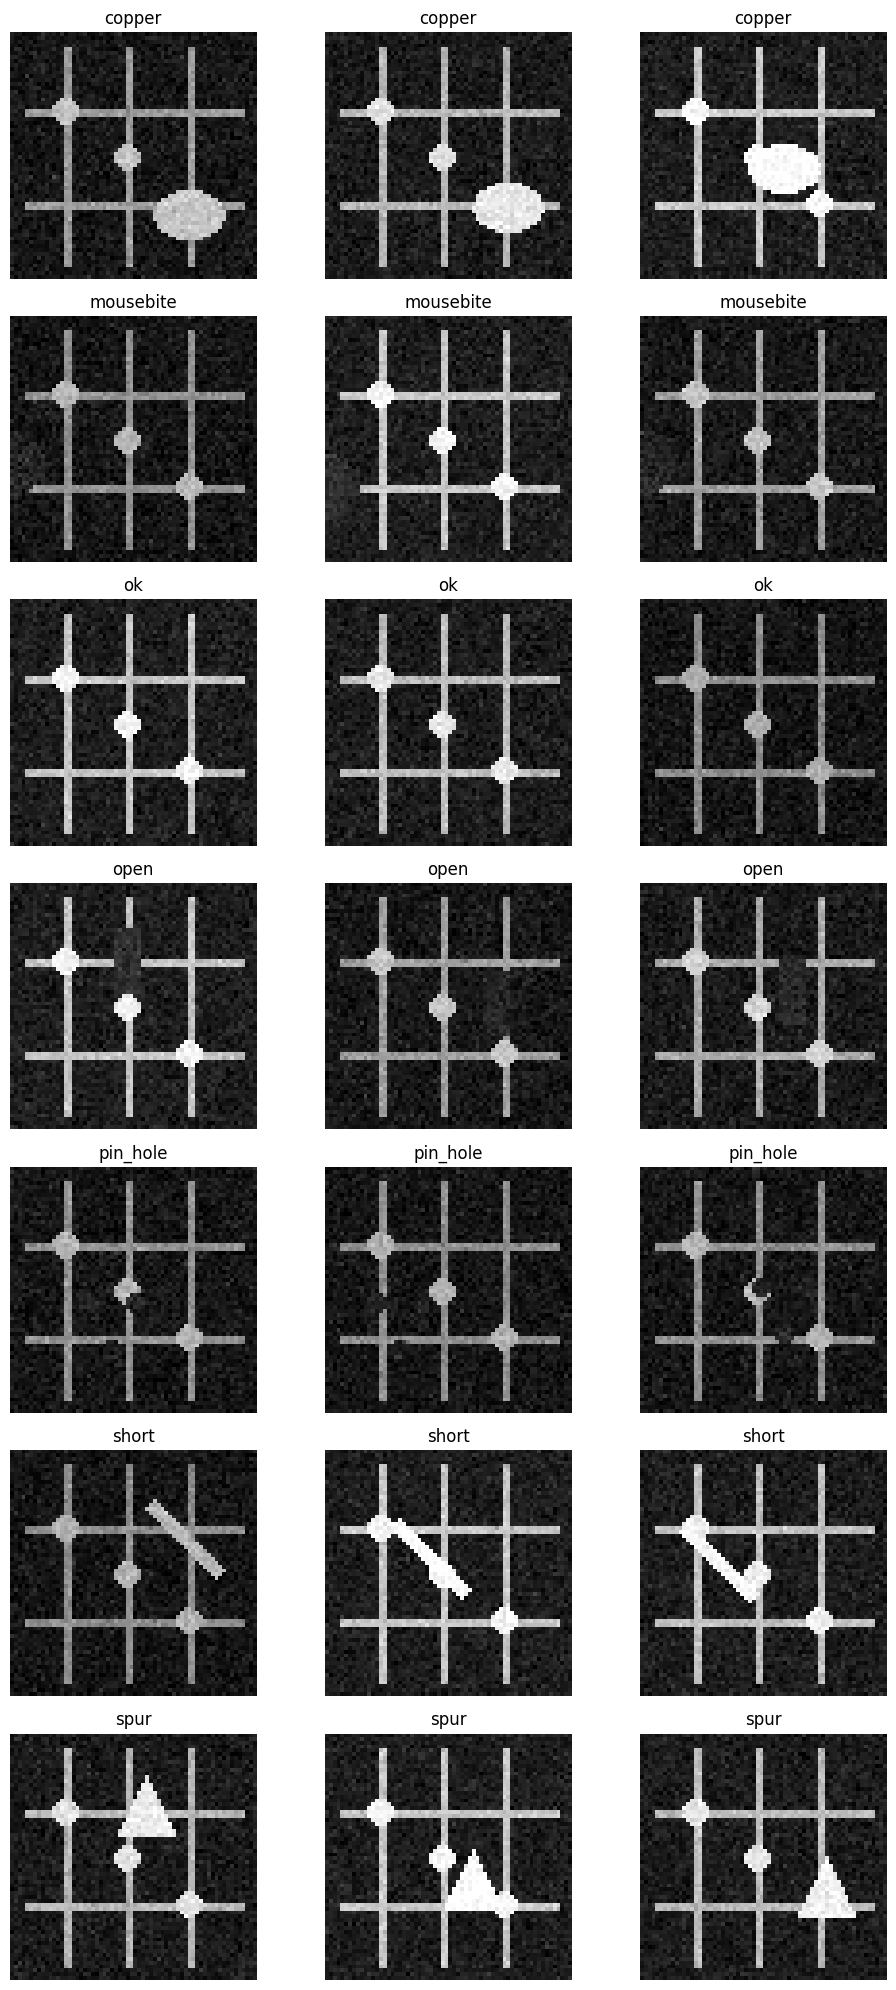

In [4]:
# TODO — 3 exemples par classe en grille 7×3
import matplotlib.pyplot as plt
from torch import random

# Affichage de 3 images par classe en grille 7x3
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(10, 20))
for i, (class_name, count) in enumerate(counts.items()):
    # On prend 3 images aléatoires de chaque classe
    all_image_paths = list((DATA_DIR / class_name).glob('*.png'))
    idx = torch.randperm(len(all_image_paths))[:3].tolist()
    image_paths = [all_image_paths[k] for k in idx]
    for j, image_path in enumerate(image_paths):
        # Conversion en RGB pour conserver les couleurs réelles des PNG (évite les faux colormaps)
        with Image.open(image_path) as img:
            axes[i, j].imshow(img.convert('RGB'))
        axes[i, j].set_title(class_name)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

#### Analyse EDA

- **Distribution des classes** : dataset équilibré, avec **300 images par classe** (`copper`, `mousebite`, `ok`, `open`, `pin_hole`, `short`, `spur`), soit **2100 images** au total.

- **Qualité d'image** :
  - Images en niveaux de gris, contraste globalement bon entre pistes PCB et fond.
  - Présence d'un bruit visuel (granularité) assez constant.
  - Résolution suffisante pour distinguer les défauts principaux, mais certains défauts peuvent rester peu visible.

C'est un dataset synthétique : ce sont des images simples générées de façon artificielle :)

- **Variabilité intra-classe** :
  - Variabilité **faible** sur la géométrie des pistes (structure très répétitive).
  - Variabilité visible surtout sur la **position**, la **taille** et parfois l'orientation locale du défaut.
  - La classe `ok` semble la plus homogène ; `copper`, `open`, `short` et `spur` montrent un peu plus de diversité de formes.

- **Ambiguïtés potentielles** :
  - Attention aux défauts de petite taille (`mousebite`, `pin_hole`) et aux images proches de `ok`.
  - Risque de confusion entre les défauts affectant la continuité des pistes (`open` vs certains cas de `mousebite` selon la zone observée).
  - Les motifs répétitifs du PCB peuvent masquer des défauts subtils si le modèle ne capte pas bien les détails locaux notamment sur `mousebite` très proche de `ok`.

- **Implication pour la suite** :
  - Le dataset équilibré est favorable à l'entraînement.
  - Il faudra surveiller la matrice de confusion sur les paires ambiguës et privilégier une approche robuste aux détails fins (augmentation légère + transfert learning).

## 2. Implémentation de l'option choisie (~4h binôme)

Cf. `decisions.md` pour le choix (A / B / C).

- Option A : `src/option_a_cnn.py` => Romain
- Option B : `src/option_b_transfer.py` => Théo
- Option C : `src/option_c_clip.py`

- Mesure : temps train (si options A ou B), latence inférence (toutes options), accuracy

### Option A : `src/option_a_cnn.py` => Romain

In [6]:
# Entraîner ou inférer l'option choisie
# Import : from src.option_a_cnn import SimpleCNN, train_one_epoch, evaluate  (idem b/c)
# Mesure : temps train (si options A ou B), latence inférence (toutes options), accuracy
import time
import torch.nn as nn

from src.option_a_cnn import SimpleCNN, train_one_epoch, evaluate

# 1) Split **aléatoire mais reproductible** des données grace à la fonction get_dataloaders() du fichier src/load_data.py (avec seed fixé à 42 pour reproductibilité)
train_loader, val_loader, test_loader = get_dataloaders(DATA_DIR, batch_size=64, seed=42)

# 2) Modèle + optimisation
model = SimpleCNN(n_classes=7).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 3) Mesure du temps d'entraînement + accuracy
n_epochs = 10
train_start = time.perf_counter()

# Cette boucle exécute l'entraînement sur plusieurs "passes complètes" du dataset (epochs).
# Le range(1, n_epochs + 1) sert à numéroter les epochs de 1 à n_epochs pour un affichage lisible.
for epoch in range(1, n_epochs + 1):
    # Entraîne le modèle sur TOUT le train_loader pour 1 epoch.
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    # Évalue ensuite le modèle sur le jeu de validation pour suivre la généralisation.
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    print(
        f"Epoch {epoch}/{n_epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

train_time_s = time.perf_counter() - train_start
print(f"\nTemps d'entraînement ({n_epochs} epochs) : {train_time_s:.2f} s")

# Accuracy finale sur test
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Accuracy test : {test_acc:.4f} | Loss test : {test_loss:.4f}")

# 4) Mesure de latence d'inférence (batch=1)
model.eval()
dummy = torch.randn(1, 1, 64, 64, device=DEVICE)

# Warm-up utile surtout sur GPU : sur CPU, on le saute pour éviter un coût inutile.
if DEVICE.type == "cuda":
    with torch.no_grad():
        for _ in range(20):
            _ = model(dummy)
    torch.cuda.synchronize()
else:
    print("Warm-up ignoré: utile surtout sur GPU.")

# Nombre de prédictions répétées pour lisser la mesure de latence.
n_runs = 200
# Démarre un chronomètre haute précision juste avant la boucle d'inférence.
start = time.perf_counter()
# Désactive les gradients : indispensable pour mesurer l'inférence pure, plus rapide et plus légère.
with torch.no_grad():
    # Exécute exactement n_runs inférences sur la même entrée factice (dummy).
    for _ in range(n_runs):
        _ = model(dummy)
# Sur GPU, on force l'attente de la fin réelle des kernels avant d'arrêter le chrono.
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

# Temps total écoulé pour les n_runs inférences.
elapsed_s = time.perf_counter() - start
# Latence moyenne par prédiction, convertie en millisecondes.
latency_ms = (elapsed_s / n_runs) * 1000
print(f"Latence moyenne inférence (batch=1, device={DEVICE}) : {latency_ms:.3f} ms")

# Vérification rapide de la dimension de sortie
print(f"Shape logits : {model(dummy).shape}")

Epoch 1/10 | train_loss=2.0356 train_acc=0.2156 | val_loss=1.9110 val_acc=0.2794
Epoch 2/10 | train_loss=1.5596 train_acc=0.3048 | val_loss=1.3920 val_acc=0.4254
Epoch 3/10 | train_loss=1.2856 train_acc=0.4150 | val_loss=1.1649 val_acc=0.4825
Epoch 4/10 | train_loss=1.0916 train_acc=0.4850 | val_loss=1.0318 val_acc=0.4667
Epoch 5/10 | train_loss=0.9995 train_acc=0.5340 | val_loss=1.1077 val_acc=0.3905
Epoch 6/10 | train_loss=0.9023 train_acc=0.6082 | val_loss=0.8266 val_acc=0.6508
Epoch 7/10 | train_loss=0.8523 train_acc=0.6340 | val_loss=0.9820 val_acc=0.4952
Epoch 8/10 | train_loss=0.7210 train_acc=0.7190 | val_loss=0.8364 val_acc=0.6063
Epoch 9/10 | train_loss=0.5760 train_acc=0.7891 | val_loss=0.4051 val_acc=0.9365
Epoch 10/10 | train_loss=0.4228 train_acc=0.8565 | val_loss=0.3486 val_acc=0.8667

Temps d'entraînement (10 epochs) : 60.40 s
Accuracy test : 0.9206 | Loss test : 0.3134
Warm-up ignoré: utile surtout sur GPU.
Latence moyenne inférence (batch=1, device=cpu) : 1.710 ms
Sha

#### Informations train_loss, train_acc, val_loss et val_acc

- `train_loss` : erreur moyenne du modèle sur le jeu **train** pendant l'epoch.
  Plus cette valeur baisse, plus le modèle apprend sur les données d'entraînement.

- `train_acc` : proportion de bonnes prédictions sur le jeu **train**.
  Exemple : `0.1912` = **19.12 %** de prédictions correctes.

- `val_loss` : erreur moyenne sur le jeu **validation** (données non utilisées pour mettre à jour les poids).
  Elle sert à vérifier la capacité de généralisation.

- `val_acc` : proportion de bonnes prédictions sur le jeu **validation**.
  Exemple : `0.1397` = **13.97 %**.

Lecture rapide de la ligne :
- `train_loss=2.1512 train_acc=0.1912 | val_loss=1.9280 val_acc=0.1397`
- Le modèle apprend un peu sur train (19.12 %), mais reste faible sur val (13.97 %), proche du hasard pour 7 classes (~14.3 %).

Repères pratiques :
- Situation saine : `train_loss` baisse, `val_loss` baisse, `val_acc` monte.
- Surapprentissage probable : `train_acc` monte mais `val_acc` stagne ou baisse.
- Sous-apprentissage : `train_acc` et `val_acc` restent tous deux faibles.

#### Exécution sur 3 EPOCH :
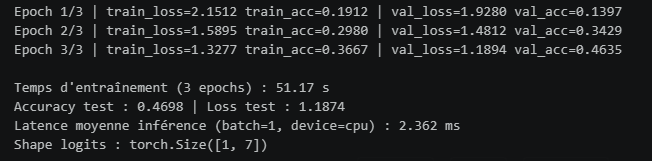

- `Accuracy test : 0.4698` : le modèle classe correctement **46.98 %** des images du jeu de test.
  Sur 7 classes, le hasard est autour de **14.3 %** (hasard = chance de tomber bon en se trompant => 7 classes donc 1 chance sur 7 d'avoir bon quand même, d'ou le 14.3 car = 1/7), donc la performance est nettement meilleure que le hasard.

- `Loss test : 1.1874` : erreur moyenne (CrossEntropy) sur le test.
  Plus cette valeur est faible, mieux c'est ; ici elle est cohérente avec une performance intermédiaire (correcte, mais encore améliorable).

- `Latence moyenne inférence (batch=1, device=cpu) : 2.362 ms` :
  une prédiction prend en moyenne **2.362 ms** sur CPU pour une image.
  C'est très rapide et compatible avec une contrainte temps réel de 100 ms.

- Lecture globale :
  précision **moyenne** mais vitesse **excellente**.
  Le modèle est déjà exploitable côté latence, et l'axe principal d'amélioration reste la précision.

#### Exécution sur 10 EPOCH :
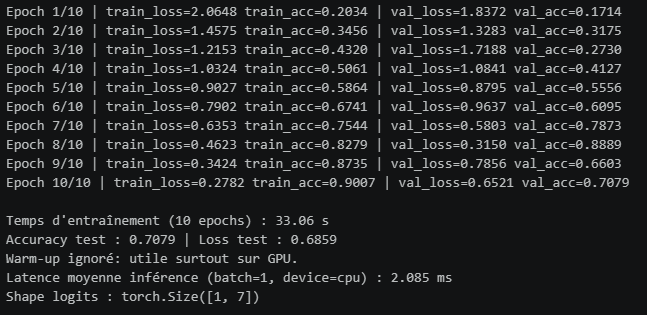

- Progression train :
  `train_acc` monte de **20.34 %** (epoch 1) à **90.07 %** (epoch 10), et `train_loss` baisse de **2.0648** à **0.2782**.
  Cela montre que le modèle apprend très bien le jeu d'entraînement.

- Progression validation :
  `val_acc` monte globalement de **17.14 %** à **70.79 %**, avec un pic à **88.89 %** (epoch 8).
  `val_loss` baisse fortement au début, puis fluctue ensuite, ce qui indique une généralisation correcte mais instable selon les epochs.

- Résultat test final :
  `Accuracy test : 0.7079` et `Loss test : 0.6859`.
  Après 10 epochs, le modèle atteint **70.79 %** sur test, nettement mieux que les résultats à 3 epochs.

- Latence finale :
  `Latence moyenne inférence (batch=1, device=cpu) : 2.085 ms`.
  La latence reste très faible malgré l'amélioration de la précision.

- Lecture globale (10 epochs) :
  bon compromis précision/latence.
  Tu gagnes fortement en performance de classification, tout en conservant un temps d'inférence compatible temps réel.

In [8]:
# Quelques variables pour les cellules suivantes
model_path_torch = Path("../models/simple_cnn.pth")
model_path_joblib = Path("../models/cnn_romain.joblib")

#### Enregistrement du modèle

⚠️⚠️⚠️ à ne pas faire, le modèle est déjà généré et commité dans le repo. ⚠️⚠️⚠️

In [ ]:
########### ⚠️⚠️⚠️ à ne pas faire, le modèle est déjà généré et commité dans le repo. ⚠️⚠️⚠️

# Enregistrement du modèle pour une utilisation future (inférence seule, pas d'entraînement)
#torch.save(model.state_dict(), model_path_torch)

from datetime import datetime, timezone
from hashlib import sha256
import json
import joblib

# joblib.dump du modèle entrainé dans ../models/cnn_romain.joblib" avec compress=3
joblib.dump(model, model_path_joblib, compress=3)
# et écrit un fichier JSON meta contenant: versions, horodatage, sha256 du dataset, hyperparamètres, métriques internes, colonnes de features et mapping de la cible.

# paramètres d'entraînement et métriques internes
hyperparameters = {
    "batch_size": 64,
    "learning_rate": 1e-3,
    "n_epochs": n_epochs,
    "optimizer": "Adam",
    "loss_function": "CrossEntropyLoss"
}
internal_metrics = {
    "train_time_s": train_time_s,
    "train_loss": train_loss,
    "train_accuracy": train_acc
}
feature_columns = ["image"]  # dans ce cas, on n'a qu'une seule feature : l'image
target_mapping = {i: class_name for i, class_name in enumerate(CLASSES)}

meta = {
    "versions": {
        "python": sys.version,
        "torch": torch.__version__,
        "joblib": joblib.__version__
    },
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "dataset_sha256": sha256(str(DATA_DIR).encode()).hexdigest(),
    "hyperparameters": hyperparameters,
    "internal_metrics": internal_metrics,
    "feature_columns": feature_columns,
    "target_mapping": target_mapping
}
with open("../models/cnn_romain_meta.json", "w") as f:
    json.dump(meta, f, indent=4)

#### Modèle sauvé
Son entrainement :

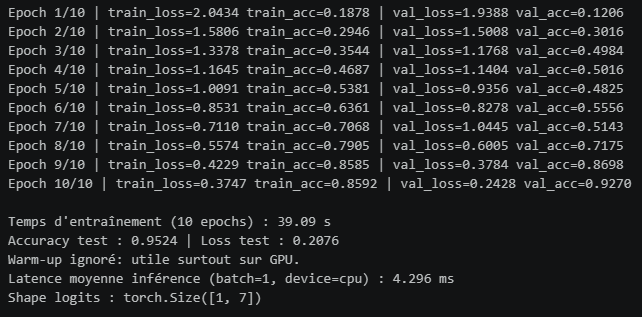

#### Test du modèle généré après entrainement

On teste le modèle CNN enregistré au dessus avec des images de ../data/test_model.
Les images ont été générées à la main en prenant des image du dataset et en les modifiant légèrement
Exemples :
- ok_test_1.png : copie d'une image ok du dataset
- ok_test_2.png : copie de ok_test_1.png avec une rotation de 90°
- ok_test_3.png : copie d'un autre image ok du dataset avec une rotation de 90° dans l'autre sens
- ok_test_4.png : copie de ok_test_1.png avec un retourner verticalement
- ok_test_5.png : copie de mousebite_0170.png avec répéaration manuelle du défaut
...

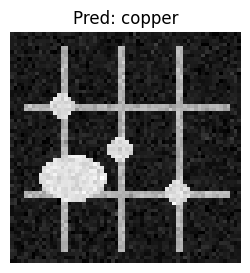

Image test: copper_0283.png
Classe attendue: copper
Classe prédite: copper


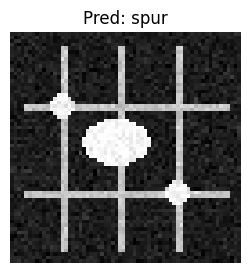

Image test: copper_0285.png
Classe attendue: copper
Classe prédite: spur


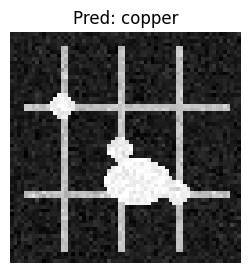

Image test: copper_0297.png
Classe attendue: copper
Classe prédite: copper


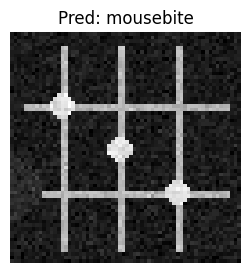

Image test: mousebite_0170.png
Classe attendue: mousebite
Classe prédite: mousebite


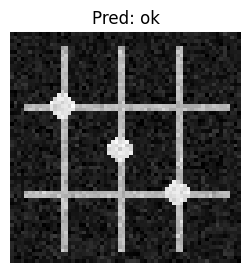

Image test: ok_0283.png
Classe attendue: ok
Classe prédite: ok


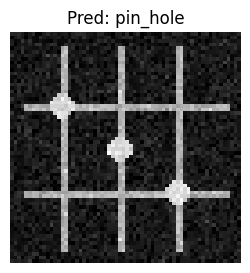

Image test: ok_test_1.png
Classe attendue: ok
Classe prédite: pin_hole


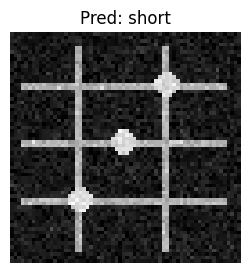

Image test: ok_test_2.png
Classe attendue: ok
Classe prédite: short


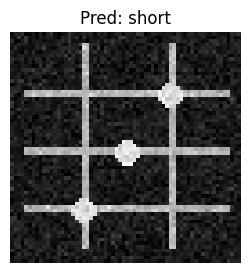

Image test: ok_test_3.png
Classe attendue: ok
Classe prédite: short


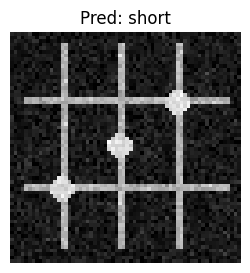

Image test: ok_test_4.png
Classe attendue: ok
Classe prédite: short


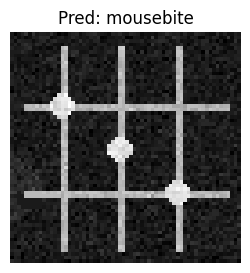

Image test: ok_test_5.png
Classe attendue: ok
Classe prédite: mousebite


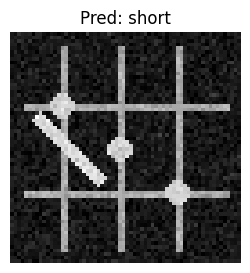

Image test: short_0185.png
Classe attendue: short
Classe prédite: short


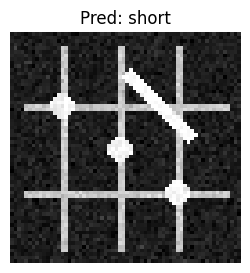

Image test: short_0276.png
Classe attendue: short
Classe prédite: short


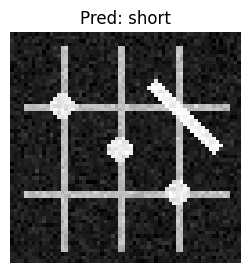

Image test: short_0290.png
Classe attendue: short
Classe prédite: short


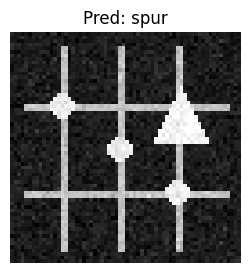

Image test: spur_0093.png
Classe attendue: spur
Classe prédite: spur


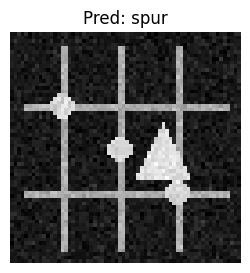

Image test: spur_0096.png
Classe attendue: spur
Classe prédite: spur


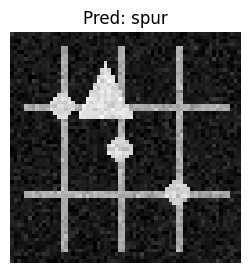

Image test: spur_0130.png
Classe attendue: spur
Classe prédite: spur


In [ ]:
# Vérification rapide : recharger le modèle et faire une prédiction sur les images de test.
from pathlib import Path
import numpy as np
import joblib

# load tensor
#model_load = torch.load(model_path_torch)
# Recharge le modèle sauvegardé
model_load = joblib.load(model_path_joblib)
model_load = model_load.to(DEVICE)
# change le comportement du modèle pour :
#  Dropout : désactivé (plus de neurones coupés aléatoirement).
#  BatchNorm : utilise les statistiques apprises pendant l’entraînement au lieu de recalculer sur le batch courant.
model_load.eval()

def preprocess_image_test(image_path: Path, device: torch.device) -> torch.Tensor:
    """Charge les images PNG en niveaux de gris et renvoie un tenseur [1, 1, 64, 64]."""
    with Image.open(image_path) as img:
        arr = np.array(img.convert("L"), dtype=np.float32) / 255.0
    x = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(device)
    return x

# Prendre les images du dossier ../data/test_ccn
for test_image_path in Path("../data/test_model").glob("*.png"):
    x = preprocess_image_test(test_image_path, DEVICE)

    with torch.no_grad():
        logits = model_load(x)
        pred_idx = int(logits.argmax(dim=1).item())
        pred_class = CLASSES[pred_idx]

    # Affichage + prédiction
    with Image.open(test_image_path) as img:
        plt.figure(figsize=(3, 3))
        plt.imshow(img.convert("L"), cmap="gray")
        plt.title(f"Pred: {pred_class}")
        plt.axis("off")
        plt.show()

    print(f"Image test: {test_image_path.name}")
    if test_image_path.name.find("ok") != -1:
        print(f"Classe attendue: ok")
    elif test_image_path.name.find("copper") != -1:
        print(f"Classe attendue: copper")
    if test_image_path.name.find("mousebite") != -1:
        print(f"Classe attendue: mousebite")
    if test_image_path.name.find("open") != -1:
        print(f"Classe attendue: open")
    if test_image_path.name.find("pin_hole") != -1:
        print(f"Classe attendue: pin_hole")
    if test_image_path.name.find("short") != -1:
        print(f"Classe attendue: short")
    if test_image_path.name.find("spur") != -1:
        print(f"Classe attendue: spur")
    print(f"Classe prédite: {pred_class}")

## 3. Comparaison économique 3 approches (~1h30)

Voir `economic_comparison.md` à remplir.

## 4. Verdict + préparation restitution duo (~1h30)

- `verdict.md` : recommandation, 8 lignes max
- Préparation restitution mardi 1ᵉʳ sept (rentrée M5) : qui dit quoi ?